# Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

1. Tracking agent behavior with logging, analytics, and debugging.
2. Transforming prompts, tool selection, and output formatting.
3. Adding retries, fallbacks, and early termination logic.
4. Applying rate limits, guardrails, and PII detection.

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## Summarization MiddleWare

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

1. Long-running conversations that exceed context windows.
2. Multi-turn dialogues with extensive history.
3. Applications where preserving full conversation context matters.

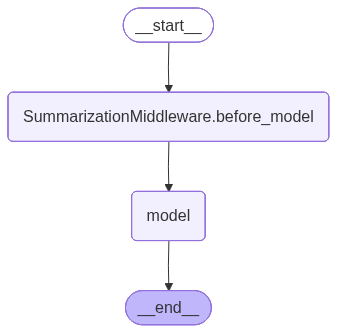

In [13]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-120b",
            trigger=('messages', 4),
            keep=('messages', 2)
        )
    ]
)

agent


In [14]:
config = {"configurable": {'thread_id': 'user1'}}

In [15]:
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for question in questions:
    response = agent.invoke({'messages': HumanMessage(content=question)}, config=config)
    print(f"Q: {question}")
    print(f"A: {response}")
    print("messages length:", len(response['messages']))

Q: What is 2+2?
A: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='34e59991-f686-4d79-b4a9-64aa526e4ff4'), AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'The user asks a simple question: "What is 2+2?" The answer is 4. There\'s no policy violation. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 78, 'total_tokens': 127, 'completion_time': 0.104821174, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.002870756, 'prompt_tokens_details': None, 'queue_time': 0.044777864, 'total_time': 0.10769193}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbf25-5590-7d21-9e88-21adac5ec00a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 49, 'total_tok

In [20]:
### token Size
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-120b",
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars

In [21]:
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~1278 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='4e15cec2-388f-4894-9560-4665951e4b81'), AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants hotels in Paris. We have a function search_hotels that takes city. Use it.', 'tool_calls': [{'id': 'fc_eedbde3a-a937-4853-8719-b36d8bb31202', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 129, 'total_tokens': 178, 'completion_time': 0.104783824, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.005990188, 'prompt_tokens_details': None, 'queue_time': 0.046030132, 'total_time': 0.110774012}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbf2b-8e03-7a30-b9e3-74

### Human in the loop middleware

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

1. High-stakes operations requiring human approval (e.g. database writes, financial transactions).
2. Compliance workflows where human oversight is mandatory.
3. Long-running conversations where human feedback guides the agent.

In [29]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

def read_email(email_id: str) -> str:
    """Simulate reading an email."""
    return f"Email {email_id}: Subject: Meeting Reminder, Body: Don't forget our meeting at 3 PM."

def send_email(recipient: str, subject: str, body: str) -> str:
    """Simulate sending an email."""
    return f"Email sent to {recipient} with subject '{subject}' and body '{body}'"
    

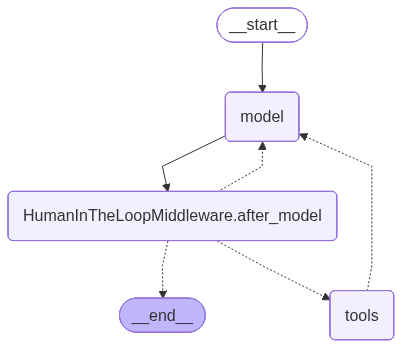

In [30]:
agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[read_email, send_email],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                'send_email': {
                    'allowed_decisions': ['approve', 'modify', 'reject']
                },
                'read_email': False  # No interruption for read_email
            }
        )
    ]
)
agent


In [36]:
config = {"configurable": {'thread_id': 'user2'}}
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='2110cb03-efe0-4bd7-a3d2-24015f205298'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email. Use send_email function.', 'tool_calls': [{'id': 'fc_e32a4fe7-9def-4310-8cf2-3f48eb36c457', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 167, 'total_tokens': 226, 'completion_time': 0.12255749, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.008131683, 'prompt_tokens_details': None, 'queue_time': 0.045084446, 'total_time': 0.130689173}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_pr

### Approval for sending email

In [37]:
from langgraph.types import Command

if '__interrupt__' in result:
    print('Applying Approval for send_email command')
    result = agent.invoke(
        Command(
            resume = {
                'decisions': [
                    {'type': 'approve',  
                    }
                ]
            }
        ),
        config=config
    )
    print(f"✅ Result: {result['messages'][-1].content}")



Applying Approval for send_email command
✅ Result: The email has been sent. Let me know if there’s anything else you’d like to do!


### Reject

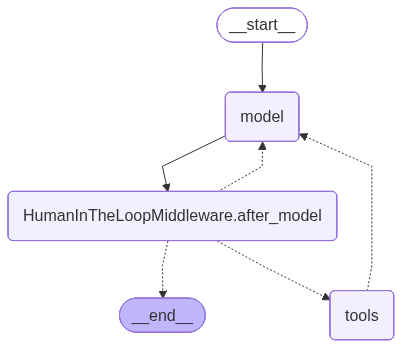

In [50]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "modify", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)
agent

In [51]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [53]:
if '__interrupt__' in result:
    print('Applying Rejection for send_email_tool command')
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    print(f"✅ Result after rejection: {result['messages'][-1].content}")

Applying Rejection for send_email_tool command
✅ Result after rejection: I’m ready to send that email, but I want to make sure everything looks correct before I do so. Here’s a preview:

- **Recipient:** john@test.com  
- **Subject:** Hello  
- **Body:** How are you?

Would you like me to go ahead and send it?


### Modify email before send

In [73]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [74]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='9d5ccb49-2d00-418a-85b2-e47abf2cccc5'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "User wants to send an email to wrong@email.com with subject 'Test' and body 'Hello'. Use send_email_tool.", 'tool_calls': [{'id': 'fc_00cc656c-f263-4071-a7f5-6960f6881d38', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 172, 'total_tokens': 242, 'completion_time': 0.149834365, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.038308005, 'prompt_tokens_details': None, 'queue_time': 0.053844525, 'total_time': 0.18814237}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_demand', 'finish_reason': 

In [75]:
if '__interrupt__' in result:
    print('Applying Modification for send_email_tool command')
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name":"send_email_tool", # tool name to modify
                            "args": { # modified arguments for the tool
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "Hello This is a modified email body."
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    print(f"✅ Result after modification: {result['messages'][-1].content}")

Applying Modification for send_email_tool command
✅ Result after modification: 
